In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [50]:
df = pd.read_csv(
    "../data/processed/Student_Attendance_Summary.csv"
)

df.head()

,Student_ID,Student_Name,College_Name,Total_Sessions,Sessions_Attended,Average_Attendance_Minutes,Attendance_Percentage,Certified
0,ST0001,Sai Reddy,VIT AP,40,37,48.700,92.5,1
1,ST0002,Rohit Gupta,Narasaraopeta Engg,40,30,40.975,75.0,0
2,ST0003,Harsha Kumar,VNR VJIET,40,28,37.375,70.0,0
3,ST0004,Praveen Gupta,Gudlavalleru Engg,40,33,43.475,82.5,1
4,ST0005,Varun Patel,Andhra Loyola,40,27,35.900,67.5,0


In [51]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 980
Columns : 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  980 non-null    object 
 1   Student_Name                980 non-null    object 
 2   College_Name                980 non-null    object 
 3   Total_Sessions              980 non-null    int64  
 4   Sessions_Attended           980 non-null    int64  
 5   Average_Attendance_Minutes  980 non-null    float64
 6   Attendance_Percentage       980 non-null    float64
 7   Certified                   980 non-null    int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 61.4+ KB


In [52]:
df.describe(include='all')

,Student_ID,Student_Name,College_Name,Total_Sessions,Sessions_Attended,Average_Attendance_Minutes,Attendance_Percentage,Certified
count,980,980,980,980.0,980.000000,980.000000,980.000000,980.000000
unique,980,179,25,NaN,NaN,NaN,NaN,NaN
top,ST0001,Arjun Singh,Gudlavalleru Engg,NaN,NaN,NaN,NaN,NaN
freq,1,11,56,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,40.0,32.429592,42.589719,81.073980,0.602041
std,NaN,NaN,NaN,0.0,5.930836,7.790616,14.827089,0.489727
min,NaN,NaN,NaN,40.0,7.000000,9.275000,17.500000,0.000000
25%,NaN,NaN,NaN,40.0,29.000000,37.543750,72.500000,0.000000
50%,NaN,NaN,NaN,40.0,33.000000,43.575000,82.500000,1.000000
75%,NaN,NaN,NaN,40.0,37.000000,49.162500,92.500000,1.000000


In [53]:
df.isnull().sum()

Student_ID                    0
Student_Name                  0
College_Name                  0
Total_Sessions                0
Sessions_Attended             0
Average_Attendance_Minutes    0
Attendance_Percentage         0
Certified                     0
dtype: int64

In [54]:
print(df.columns.tolist())

['Student_ID', 'Student_Name', 'College_Name', 'Total_Sessions', 'Sessions_Attended', 'Average_Attendance_Minutes', 'Attendance_Percentage', 'Certified']


In [55]:
print(df.shape)
df.head()

(980, 8)


,Student_ID,Student_Name,College_Name,Total_Sessions,Sessions_Attended,Average_Attendance_Minutes,Attendance_Percentage,Certified
0,ST0001,Sai Reddy,VIT AP,40,37,48.700,92.5,1
1,ST0002,Rohit Gupta,Narasaraopeta Engg,40,30,40.975,75.0,0
2,ST0003,Harsha Kumar,VNR VJIET,40,28,37.375,70.0,0
3,ST0004,Praveen Gupta,Gudlavalleru Engg,40,33,43.475,82.5,1
4,ST0005,Varun Patel,Andhra Loyola,40,27,35.900,67.5,0


In [56]:
df['Certified'] = np.where(
    df['Attendance_Percentage'] >= 80,
    1,
    0
)

df['Certified'].value_counts()

Certified
1    590
0    390
Name: count, dtype: int64

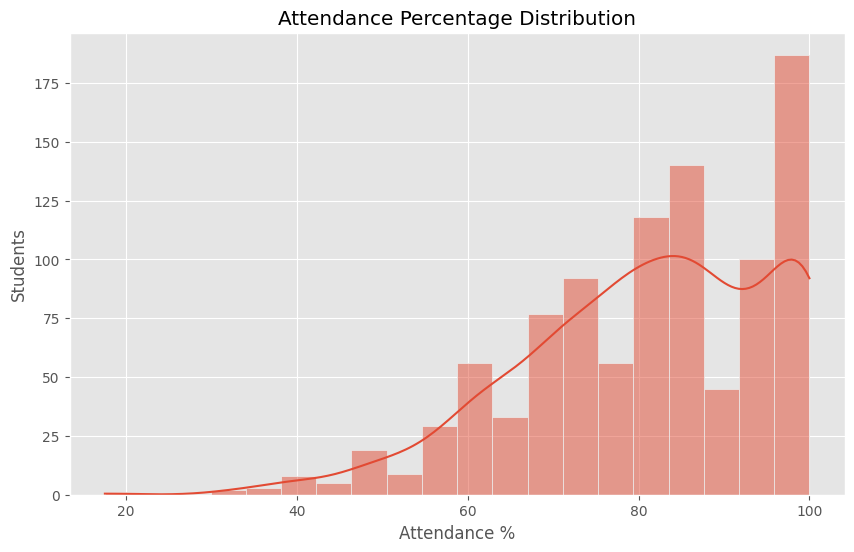

In [57]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Attendance_Percentage'],
    bins=20,
    kde=True
)

plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance %")
plt.ylabel("Students")

plt.savefig(
    "../visualizations/attendance_distribution.png"
)

plt.show()

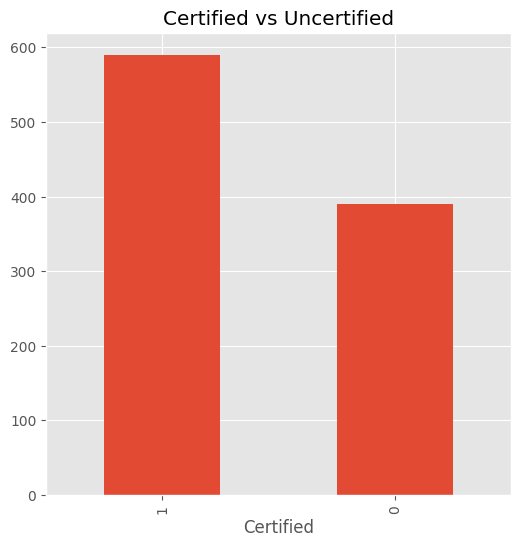

In [58]:
plt.figure(figsize=(6,6))

df['Certified'].value_counts().plot(
    kind='bar'
)

plt.title("Certified vs Uncertified")

plt.savefig(
    "../visualizations/certified_vs_uncertified.png"
)

plt.show()

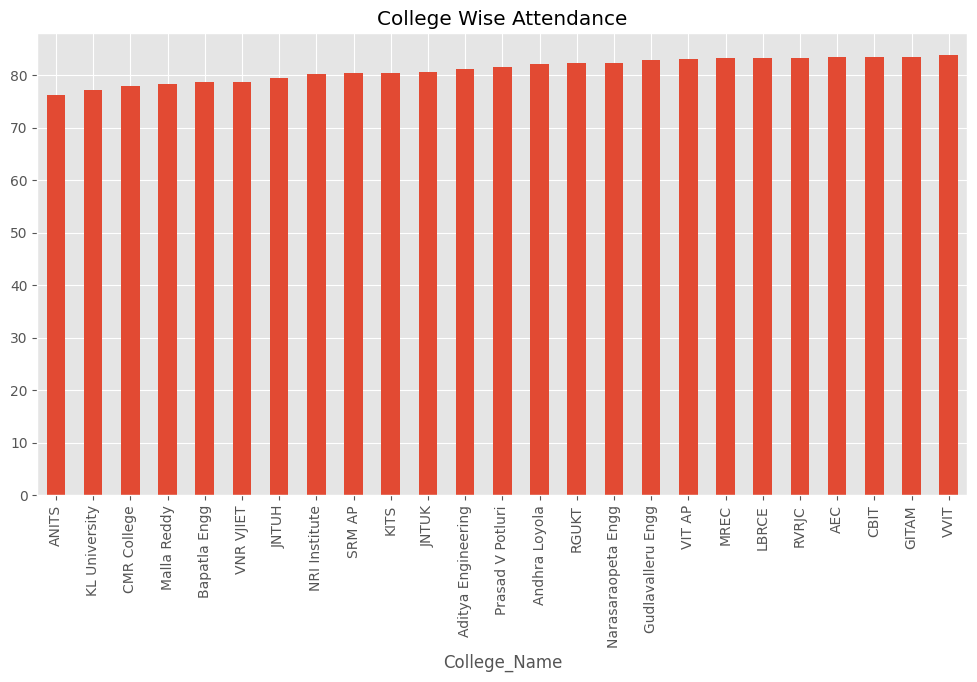

In [59]:
college_avg = df.groupby(
    'College_Name'
)['Attendance_Percentage'].mean()

college_avg.sort_values().plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("College Wise Attendance")

plt.savefig(
    "../visualizations/college_wise_attendance.png"
)

plt.show()

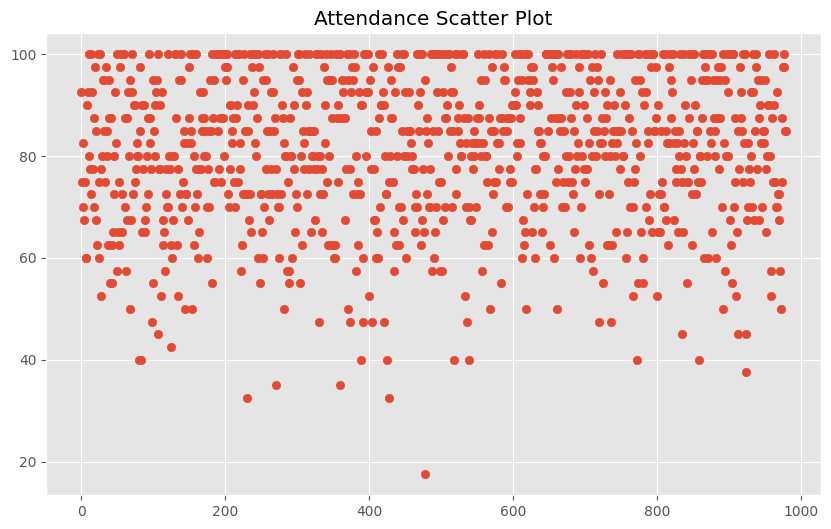

In [60]:
plt.figure(figsize=(10,6))

plt.scatter(
    range(len(df)),
    df['Attendance_Percentage']
)

plt.title("Attendance Scatter Plot")

plt.savefig(
    "../visualizations/attendance_scatter_plot.png"
)

plt.show()

In [61]:
df.head()
print(df.columns.tolist())

['Student_ID', 'Student_Name', 'College_Name', 'Total_Sessions', 'Sessions_Attended', 'Average_Attendance_Minutes', 'Attendance_Percentage', 'Certified']


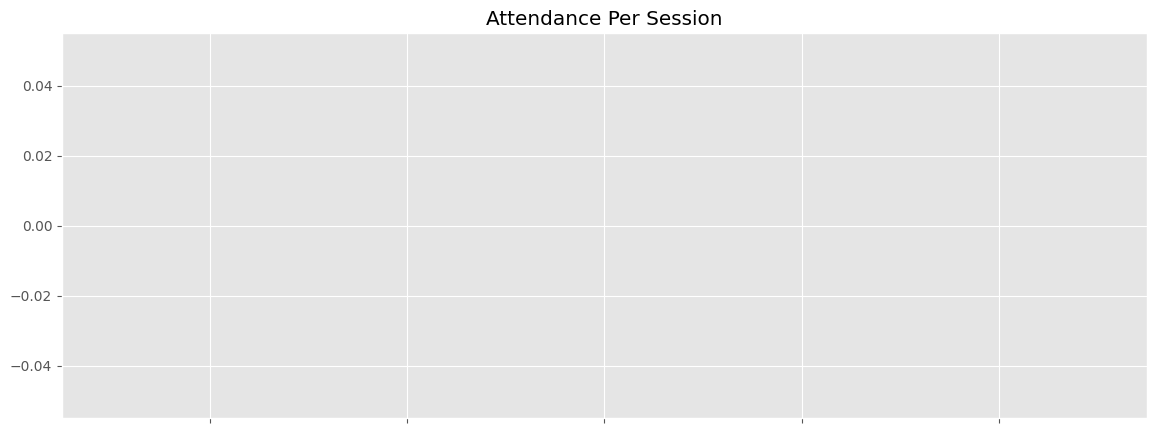

In [62]:
session_cols = [
    col for col in df.columns
    if "Session_" in col
]

attendance_per_session = (
    df[session_cols]
    .sum()
)

attendance_per_session.plot(
    figsize=(14,5)
)

plt.title("Attendance Per Session")
plt.show()

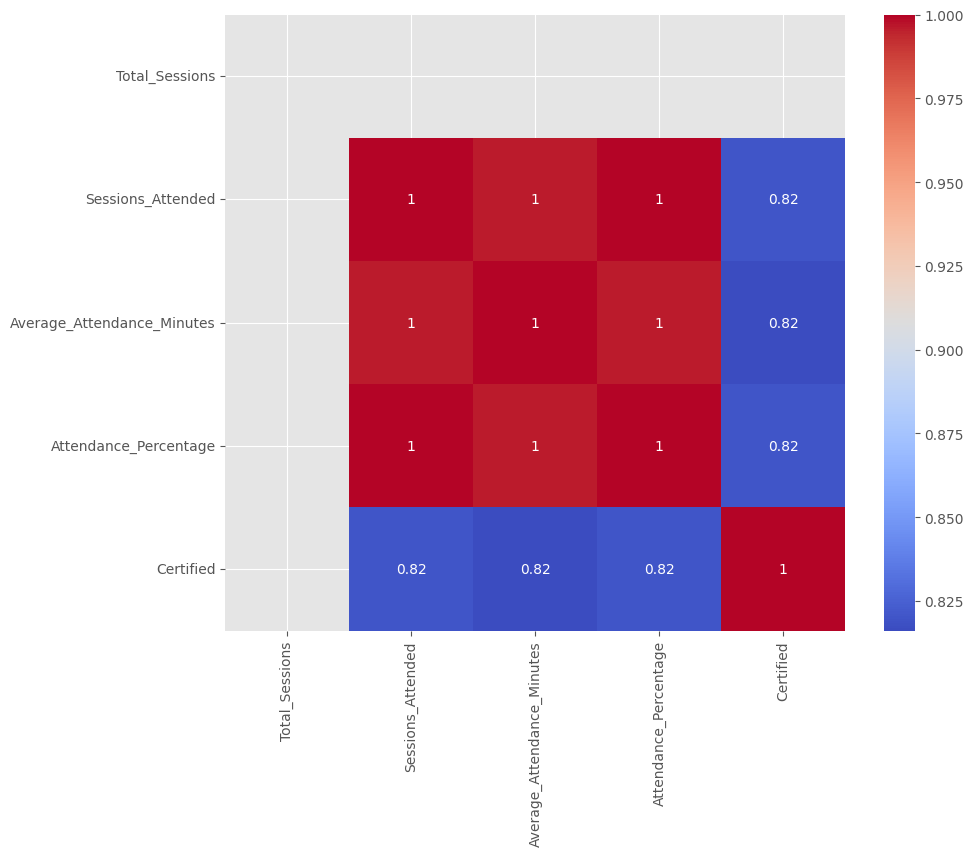

In [63]:
numeric_df = df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()